# Modul 15B — Etika, Privasi & Bias dalam Sistem AI
## Convergeni Data Consulting (CDC) — Klien: Bank Arta Nusantara

Notebook ini menjalankan audit fairness Modul 15B: proxy discrimination lewat
pendapatan, disparate impact ratio, dan FNR per kelompok gender.

## Data dan Model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

np.random.seed(42)
n = 800
jenis_kelamin = np.random.choice(["Perempuan", "Laki-laki"], size=n, p=[0.5, 0.5])
base_pendapatan = np.random.normal(14, 6, n)
gap_factor = np.where(jenis_kelamin == "Perempuan", 0.80, 1.0)
pendapatan_juta = np.clip(base_pendapatan * gap_factor, 4, 60)
usia = np.clip(np.random.normal(37, 9, n), 21, 65).round().astype(int)
skor_kredit = np.clip(0.7 * pendapatan_juta + np.random.normal(55, 10, n), 20, 100)
jumlah_tanggungan = np.clip(np.random.poisson(1.8, n), 0, 6)
rasio_cicilan_pendapatan = np.clip(np.random.normal(0.32, 0.12, n), 0.05, 0.9)
jenis_kredit = np.random.choice(["KPR", "UMKM"], size=n, p=[0.55, 0.45])
logit = (-3.2 - 0.05 * (skor_kredit - 60) + 4.5 * (rasio_cicilan_pendapatan - 0.3)
    + 0.18 * jumlah_tanggungan - 0.01 * (usia - 37) + np.where(jenis_kredit == "UMKM", 0.4, 0.0))
gagal_bayar = np.random.binomial(1, 1 / (1 + np.exp(-logit)))
df = pd.DataFrame({"pendapatan_juta": pendapatan_juta.round(2), "usia": usia,
    "skor_kredit": skor_kredit.round(1), "jumlah_tanggungan": jumlah_tanggungan,
    "rasio_cicilan_pendapatan": rasio_cicilan_pendapatan.round(3),
    "jenis_kredit": jenis_kredit, "jenis_kelamin": jenis_kelamin, "gagal_bayar": gagal_bayar})

ringkasan_gender = df.groupby("jenis_kelamin")[["pendapatan_juta", "skor_kredit", "gagal_bayar"]].mean()
print(ringkasan_gender.round(4))

               pendapatan_juta  skor_kredit  gagal_bayar
jenis_kelamin                                           
Laki-laki              14.4452      65.1755       0.0417
Perempuan              11.7099      63.3273       0.0765


## Visualisasi 1: Proxy Discrimination Lewat Pendapatan (Asset Baru, mengganti M15B-01)

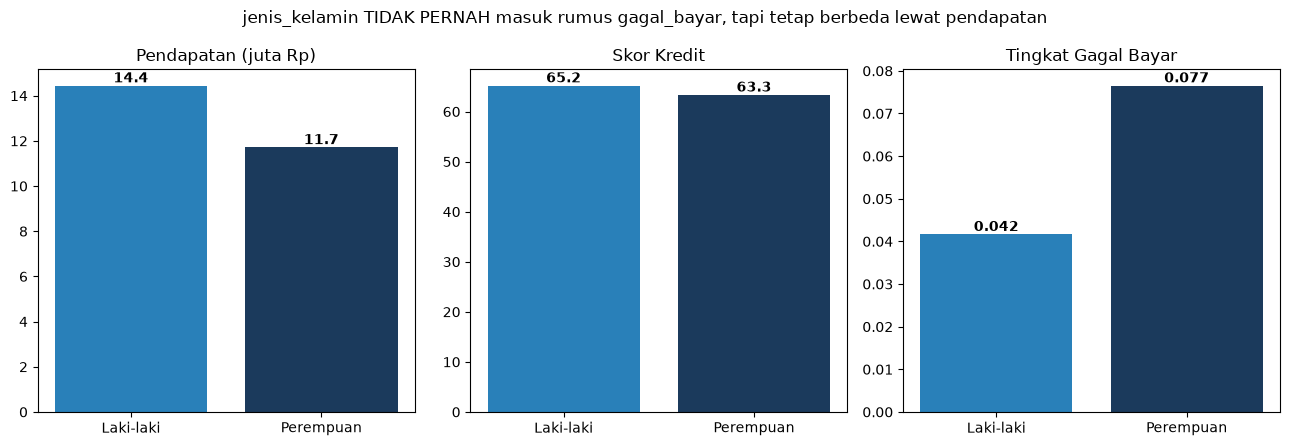

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
metrik = ["pendapatan_juta", "skor_kredit", "gagal_bayar"]
judul = ["Pendapatan (juta Rp)", "Skor Kredit", "Tingkat Gagal Bayar"]
for ax, m, j in zip(axes, metrik, judul):
    ax.bar(ringkasan_gender.index, ringkasan_gender[m], color=["#2980B9", "#1B3A5C"])
    ax.set_title(j)
    for i, v in enumerate(ringkasan_gender[m]):
        ax.text(i, v, f"{v:.3f}" if m == "gagal_bayar" else f"{v:.1f}", ha="center", va="bottom", fontweight="bold")
fig.suptitle("jenis_kelamin TIDAK PERNAH masuk rumus gagal_bayar, tapi tetap berbeda lewat pendapatan")
plt.tight_layout()
plt.savefig("modul15b_proxy_discrimination.png", dpi=150, bbox_inches="tight")
plt.show()

## Disparate Impact dan FNR

In [3]:
fitur_numerik = ["pendapatan_juta", "usia", "skor_kredit", "jumlah_tanggungan", "rasio_cicilan_pendapatan"]
fitur_kategorikal = ["jenis_kredit"]
X = df[fitur_numerik + fitur_kategorikal]
y = df["gagal_bayar"]
X_train, X_test, y_train, y_test, gender_train, gender_test = train_test_split(
    X, y, df["jenis_kelamin"], test_size=0.25, random_state=42, stratify=y)

preprocessor = ColumnTransformer([("num", StandardScaler(), fitur_numerik), ("cat", OneHotEncoder(drop="first"), fitur_kategorikal)])
pipeline = Pipeline([("pre", preprocessor), ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))])
pipeline.fit(X_train, y_train)
proba_test = pipeline.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= 0.60).astype(int)

hasil = pd.DataFrame({"gender": gender_test.values, "ditolak": pred_test, "actual": y_test.values})
tingkat_setuju = 1 - hasil.groupby("gender")["ditolak"].mean()
rasio_di = tingkat_setuju["Perempuan"] / tingkat_setuju["Laki-laki"]
print("Tingkat disetujui:", tingkat_setuju.to_dict())
print(f"Disparate impact ratio: {rasio_di:.4f}")

fnr_per_gender = {}
for g in ["Laki-laki", "Perempuan"]:
    subset = hasil[hasil["gender"] == g]
    tn, fp, fn, tp = confusion_matrix(subset["actual"], subset["ditolak"]).ravel()
    fnr_per_gender[g] = fn / (fn + tp) if (fn + tp) > 0 else float("nan")
    print(f"{g}: FNR={fnr_per_gender[g]:.4f}, n_gagal_bayar={fn+tp}")

Tingkat disetujui: {'Laki-laki': 0.8240740740740741, 'Perempuan': 0.8152173913043479}
Disparate impact ratio: 0.9893
Laki-laki: FNR=0.6000, n_gagal_bayar=5
Perempuan: FNR=0.7143, n_gagal_bayar=7


## Visualisasi 2: Dua Definisi Fairness, Dua Kesimpulan Berbeda (Asset Baru, mengganti M15B-02)

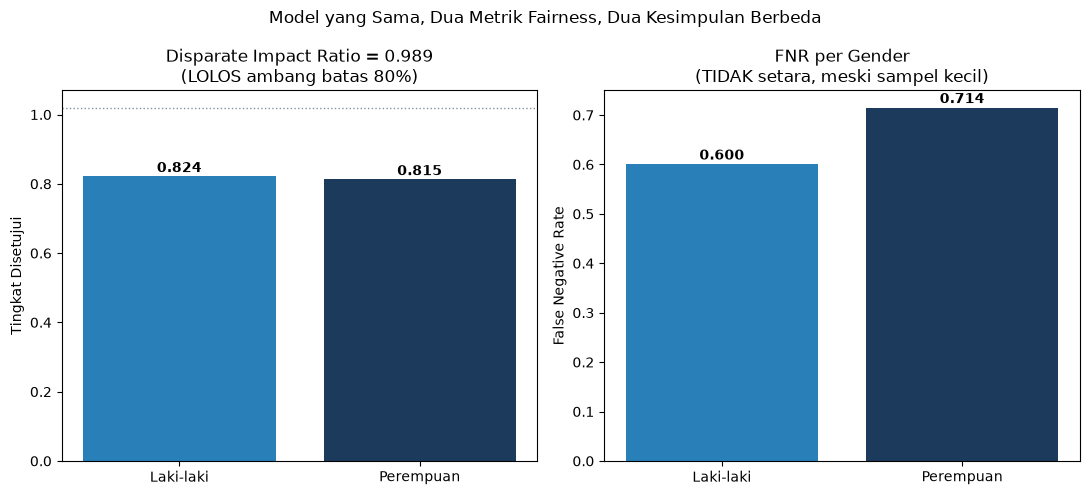

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].bar(tingkat_setuju.index, tingkat_setuju.values, color=["#2980B9", "#1B3A5C"])
axes[0].axhline(tingkat_setuju.min() / 0.8, color="#85929E", linestyle=":", linewidth=1)
axes[0].set_title(f"Disparate Impact Ratio = {rasio_di:.3f}\n(LOLOS ambang batas 80%)")
axes[0].set_ylabel("Tingkat Disetujui")
for i, v in enumerate(tingkat_setuju.values):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha="center", fontweight="bold")

axes[1].bar(list(fnr_per_gender.keys()), list(fnr_per_gender.values()), color=["#2980B9", "#1B3A5C"])
axes[1].set_title("FNR per Gender\n(TIDAK setara, meski sampel kecil)")
axes[1].set_ylabel("False Negative Rate")
for i, (g, v) in enumerate(fnr_per_gender.items()):
    axes[1].text(i, v + 0.01, f"{v:.3f}", ha="center", fontweight="bold")

fig.suptitle("Model yang Sama, Dua Metrik Fairness, Dua Kesimpulan Berbeda")
plt.tight_layout()
plt.savefig("modul15b_dua_definisi_fairness.png", dpi=150, bbox_inches="tight")
plt.show()